In [1]:
import numpy as np
from robotdataset import list_datasets, OXEDataset, TemporalSampler, EpisodeTubeletSampler, batchViz, itemViz, episodeViz


/home/zeus/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1781194959.962895    4350 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781194961.286072    4350 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781194963.919645    4350 port.cc:153] oneDNN custom operations are on. You may se

In [2]:
list_datasets()

W0000 00:00:1781175391.934547   12625 google_auth_provider.cc:196] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Could not resolve hostname', error details: Could not resolve host: metadata.google.internal".


{'aloha_mobile': ['0.0.1'],
 'asimov_dilemmas_scifi_train': ['0.1.0'],
 'asimov_dilemmas_auto_val': ['0.1.0'],
 'asimov_v2_constraints_with_rationale': ['0.1.0'],
 'asimov_v2_constraints_without_rationale': ['0.1.0'],
 'agent_aware_affordances': ['1.0.0'],
 'asimov_multimodal_robopair_val': ['0.1.0'],
 'asimov_multimodal_manual_val': ['0.1.0'],
 'austin_buds_dataset_converted_externally_to_rlds': ['0.1.0'],
 'asimov_v2_injuries': ['0.1.0'],
 'asimov_dilemmas_scifi_val': ['0.1.0'],
 'asimov_injury_val': ['0.1.0'],
 'asimov_multimodal_auto_val': ['0.1.0'],
 'asu_table_top_converted_externally_to_rlds': ['0.1.0'],
 'berkeley_mvp_converted_externally_to_rlds': ['0.1.0'],
 'berkeley_cable_routing': ['0.1.0'],
 'asimov_v2_videos': ['0.1.0'],
 'berkeley_autolab_ur5': ['0.1.0'],
 'bridge': ['0.1.0'],
 'austin_sailor_dataset_converted_externally_to_rlds': ['0.1.0'],
 'austin_sirius_dataset_converted_externally_to_rlds': ['0.1.0'],
 'cmu_franka_exploration_dataset_converted_externally_to_rlds': 

In [ ]:
dataset = OXEDataset(
    # dataset_name = "cmu_playing_with_food",
    dataset_name = "viola",
    episodes = [ep for ep in range(10)],
    batch_size = 6,
    control_frequency=5,
    # load
)

W0000 00:00:1781194969.396108    4350 google_auth_provider.cc:196] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Could not resolve hostname', error details: Could not resolve host: metadata.google.internal".


In [4]:
# sampler = EpisodeNthSecondSampler(
#     n = 2,
#     control_frequency = 10
# )
# dataset.set_sampler(sampler)

In [3]:
sampler = TemporalSampler(
    delta_timestamps={
        dataset.image_keys[0]: np.arange(-1, 0, 1/10).tolist(),
        # "observation/finger_vision_1": np.arange(-3, 0, 1/10).tolist(),
    },
    control_frequency=10
)
dataset.set_sampler(sampler=sampler)

In [4]:
dataset.modalities

{'image': ['observation/agentview_rgb', 'observation/eye_in_hand_rgb'],
 'text': ['observation/natural_language_embedding',
  'observation/natural_language_instruction'],
 'state': ['observation/ee_states',
  'observation/gripper_states',
  'observation/joint_states'],
 'action': ['action/gripper_closedness_action',
  'action/rotation_delta',
  'action/terminate_episode',
  'action/world_vector']}

In [5]:
dataset.image_keys[0]

'observation/agentview_rgb'

In [8]:
dataset.num_episodes
# len(dataset)

10

In [22]:
dataset._episode_starts[1], dataset._episode_lengths[5]

(481, 448)

In [23]:
dataset[482]["observation"]["natural_language_instruction"]

'arrange plate and fork'

In [21]:
episodeViz(dataset, 1, key=dataset.image_keys[0], fps=10, is_output_video=True)

In [12]:
batch = next(iter(dataset))
# batch = batch.flatten_keys()

In [ ]:
batch[dataset.image_keys

TypeError: new(): invalid data type 'str'

AttributeError: 'OXEDataset' object has no attribute 'episode_id_key'

In [21]:
batch["collector/episode_id"]

tensor([8, 4, 4, 1, 9, 3])

In [21]:
dataset.image_keys[0]

('observation', 'agentview_rgb')

In [11]:
batch[dataset.image_keys[0]].shape

torch.Size([25, 224, 224, 3])

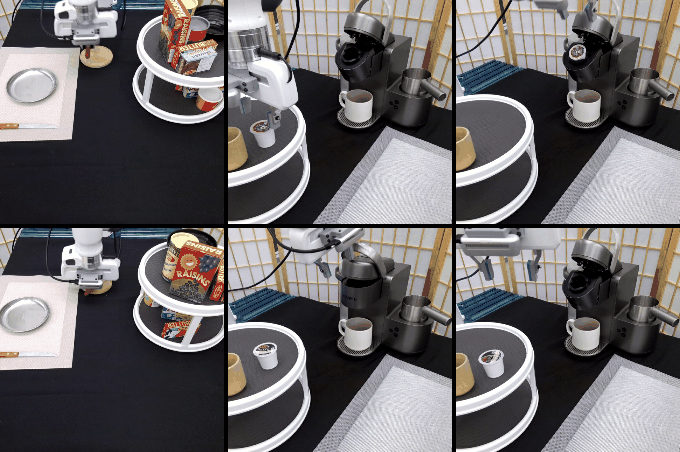

In [23]:
batchViz(batch, key=dataset.image_keys[0])

In [25]:
itemViz(batch, 0, key=dataset.image_keys[0], is_output_video=True)

In [ ]:
len(dataset.builder.as_dataset("train"))

1500

In [ ]:
len(dataset)

244

In [ ]:
dataset.num_episodes

2

In [ ]:
len(dataset)

321

In [ ]:
dataset[168]["done"]

MemoryMappedTensor([True])

In [ ]:
dataset[169]["collector"]["traj_ids"]

MemoryMappedTensor(2)

In [ ]:
batch = next(iter(dataset))

In [ ]:
batch

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([4, 7]), device=cpu, dtype=torch.float32, is_shared=False),
        collector: TensorDict(
            fields={
                episode_id: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.int64, is_shared=False)},
            batch_size=torch.Size([4]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        language_instruction: NonTensorStack(
            ['\nCaressingly guide your clamp towards the toast...,
            batch_size=torch.Size([4]),
            device=cpu),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: TensorDict(
                    fields={
                        image: Tensor(shape=torch.Size([4, 128, 128, 3]), device=cpu, dtype=torch.uint8, is_shared=False),
     